# Compare Two Pine Scripts

Pairwise deep-dive for the TactiX reward-distribution pipeline.

Compares two `.pine` scripts against each other using the stored embeddings
from **both** models (`qwen3-embedding:0.6b` and `qwen3-embedding:4b`), plus an
optional chunk-level breakdown via live Ollama embedding.

**Run order:** top to bottom. Edit `FILE_A` / `FILE_B` in the config cell to
choose which scripts to compare.

| Verdict | Threshold | Meaning |
|---|---|---|
| REMIX | sim >= 0.93 | likely a derivative — reward split recommended |
| related | sim >= 0.75 | same design family — reported, no split |
| distinct | sim < 0.75 | unrelated design |

In [1]:
import json
import sys
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path.cwd()))
import embed_indicators as ei  # reuse strip_header / chunk_source / embed fns

DB_06 = Path('indicator_embeddings.json')
DB_4B = Path('indicator_embeddings_qwen3-embedding_4b.json')

def load_vectors(db_path):
    if not db_path.exists():
        return None
    db = json.loads(db_path.read_text())
    return {n: np.asarray(e['vector']) for n, e in db['indicators'].items()}, db['model']

MODELS = {}
for label, path in [('0.6b', DB_06), ('4b', DB_4B)]:
    res = load_vectors(path)
    if res:
        vecs, model_name = res
        MODELS[label] = vecs
        print(f'{label}: loaded {len(vecs)} vectors from {path.name} (model={model_name})')
    else:
        print(f'{label}: {path.name} not found — skipped')

all_names = sorted(set().union(*(v.keys() for v in MODELS.values())))

0.6b: loaded 26 vectors from indicator_embeddings.json (model=qwen3-embedding:0.6b)
4b: loaded 26 vectors from indicator_embeddings_qwen3-embedding_4b.json (model=qwen3-embedding:4b)


In [2]:
# ---- CONFIG: pick the two scripts to compare --------------------------
# Edit the names below, then re-run the cells below this one.
# Uncomment the print to list all available scripts.

FILE_A = '04_Pulse_mean_acc.pine'
FILE_B = '04_Pulse_mean_acc_strategy.pine'

# print('\n'.join(all_names))

# ---------------------------------------------------------------------
# OPTIONAL: interactive dropdowns — works in JupyterLab/VS Code, but NOT
# in all notebook viewers (renders "Could not render content" there).
# Uncomment if your viewer supports ipywidgets:
#
# import ipywidgets as widgets
# dd_a = widgets.Dropdown(options=all_names, value=FILE_A, description='A:')
# dd_b = widgets.Dropdown(options=all_names, value=FILE_B, description='B:')
# def _sync(*_):
#     global FILE_A, FILE_B
#     FILE_A, FILE_B = dd_a.value, dd_b.value
# dd_a.observe(_sync, 'value'); dd_b.observe(_sync, 'value')
# display(widgets.HBox([dd_a, dd_b]))

In [3]:
def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

def verdict(sim):
    if sim >= ei.REMIX_THRESHOLD:
        return 'REMIX — reward split recommended'
    if sim >= ei.RELATED_THRESHOLD:
        return 'related — same design family'
    return 'distinct'

print(f'A: {FILE_A}')
print(f'B: {FILE_B}\n')
print(f"{'model':<6} {'cosine':>8}   verdict")
print('-' * 60)
for label, vecs in MODELS.items():
    if FILE_A not in vecs or FILE_B not in vecs:
        missing = FILE_A if FILE_A not in vecs else FILE_B
        print(f'{label:<6}   n/a     ({missing} not embedded)')
        continue
    s = cosine(vecs[FILE_A], vecs[FILE_B])
    print(f'{label:<6} {s:>8.4f}   {verdict(s)}')

A: 04_Pulse_mean_acc.pine
B: 04_Pulse_mean_acc_strategy.pine

model    cosine   verdict
------------------------------------------------------------
0.6b     0.9618   REMIX — reward split recommended
4b       0.9594   REMIX — reward split recommended


## Nearest neighbours

For context: each script's top-8 most similar scripts in each model.
If A and B are true parent/child, they should be each other's #1 (or near-top)
in both models, and their neighbour lists should overlap heavily.

In [4]:
def top_neighbours(vecs, name, k=8):
    sims = [(n, cosine(vecs[name], v)) for n, v in vecs.items() if n != name]
    return sorted(sims, key=lambda t: -t[1])[:k]

for label, vecs in MODELS.items():
    if FILE_A not in vecs or FILE_B not in vecs:
        continue
    print(f'\n=== {label} ===')
    na, nb = top_neighbours(vecs, FILE_A), top_neighbours(vecs, FILE_B)
    rank_a_in_b = next((i + 1 for i, (n, _) in enumerate(top_neighbours(vecs, FILE_B, k=len(vecs))) if n == FILE_A), None)
    rank_b_in_a = next((i + 1 for i, (n, _) in enumerate(top_neighbours(vecs, FILE_A, k=len(vecs))) if n == FILE_B), None)
    print(f'  B ranks #{rank_b_in_a} among A\'s neighbours | A ranks #{rank_a_in_b} among B\'s')
    print(f"  {'A neighbours':<45} {'B neighbours':<45}")
    for i in range(max(len(na), len(nb))):
        la = f'{na[i][0]} ({na[i][1]:.4f})' if i < len(na) else ''
        lb = f'{nb[i][0]} ({nb[i][1]:.4f})' if i < len(nb) else ''
        mark = ' <== OTHER' if (i < len(na) and na[i][0] == FILE_B) or (i < len(nb) and nb[i][0] == FILE_A) else ''
        print(f'  {la:<45} {lb:<45}{mark}')


=== 0.6b ===
  B ranks #1 among A's neighbours | A ranks #1 among B's
  A neighbours                                  B neighbours                                 
  04_Pulse_mean_acc_strategy.pine (0.9618)      04_Pulse_mean_acc.pine (0.9618)               <== OTHER
  triexdev.pine (0.7402)                        mtf_ema.pine (0.7393)                        
  MACD_Beluga.pine (0.7224)                     triexdev.pine (0.7232)                       
  07_Nexus_Fusion.pine (0.6979)                 macd_ema.pine (0.7145)                       
  02_zeierman_trend_strategy.pine (0.6948)      02_zeierman_trend_strategy.pine (0.7144)     
  02_zeierman_trend.pine (0.6840)               Divergency.pine (0.7074)                     
  mtf_ema.pine (0.6774)                         MACD_Beluga.pine (0.7069)                    
  POC.pine (0.6761)                             12_macd_crossover.pine (0.7058)              

=== 4b ===
  B ranks #1 among A's neighbours | A ranks #1 among B's
  A 

## Chunk-level comparison (live embedding)

The stored vectors are mean-pooled over overlapping chunks, which hides *where*
the two scripts overlap. This cell re-embeds both files chunk-by-chunk via
Ollama and shows the pairwise chunk similarity — high-similarity bands reveal
which regions were copied/remixed.

**Cost:** one Ollama call per chunk pair set — fast on `0.6b`, slow on `4b`.
Set `LIVE_MODEL` below.

In [5]:
LIVE_MODEL = 'qwen3-embedding:0.6b'  # 'qwen3-embedding:4b' is ~10x slower

ei.MODEL = LIVE_MODEL

src_a = (ei.INDICATOR_DIR / FILE_A).read_text(encoding='utf-8', errors='replace')
src_b = (ei.INDICATOR_DIR / FILE_B).read_text(encoding='utf-8', errors='replace')

chunks_a = ei.chunk_source(ei.strip_header(src_a))
chunks_b = ei.chunk_source(ei.strip_header(src_b))
print(f'{FILE_A}: {len(chunks_a)} chunks | {FILE_B}: {len(chunks_b)} chunks')

vecs_a = ei.embed_texts(chunks_a)
vecs_b = ei.embed_texts(chunks_b)
vecs_a /= np.linalg.norm(vecs_a, axis=1, keepdims=True) + 1e-12
vecs_b /= np.linalg.norm(vecs_b, axis=1, keepdims=True) + 1e-12
sim_matrix = vecs_a @ vecs_b.T  # (len a) x (len b)
print(f'chunk-pair similarity: max={sim_matrix.max():.4f}  mean={sim_matrix.mean():.4f}')

04_Pulse_mean_acc.pine: 2 chunks | 04_Pulse_mean_acc_strategy.pine: 2 chunks


chunk-pair similarity: max=0.9919  mean=0.8730


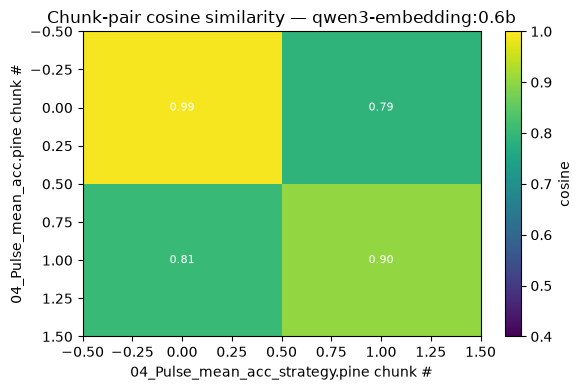

In [6]:
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(max(6, len(chunks_b)), max(4, len(chunks_a) * 0.5)))
    im = ax.imshow(sim_matrix, cmap='viridis', vmin=0.4, vmax=1.0, aspect='auto')
    ax.set_xlabel(f'{FILE_B} chunk #')
    ax.set_ylabel(f'{FILE_A} chunk #')
    ax.set_title(f'Chunk-pair cosine similarity — {LIVE_MODEL}')
    for i in range(sim_matrix.shape[0]):
        for j in range(sim_matrix.shape[1]):
            ax.text(j, i, f'{sim_matrix[i, j]:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if sim_matrix[i, j] > 0.7 else 'black')
    fig.colorbar(im, ax=ax, label='cosine')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib not installed — text heatmap:')
    hdr = '      ' + ''.join(f'{j:>7}' for j in range(sim_matrix.shape[1]))
    print(hdr)
    for i in range(sim_matrix.shape[0]):
        print(f'{i:>4}  ' + ''.join(f'{sim_matrix[i, j]:>7.3f}' for j in range(sim_matrix.shape[1])))

In [7]:
# Region-level summary: for each chunk of A, its best match in B.
# Uniformly high -> full-file remix. Patchy high -> partial reuse.
best = sim_matrix.max(axis=1)
argbest = sim_matrix.argmax(axis=1)
print(f'{"A chunk":>7} {"best B chunk":>12} {"sim":>7}  region verdict')
for i, (s, j) in enumerate(zip(best, argbest)):
    v = 'copied' if s >= ei.REMIX_THRESHOLD else ('borrowed' if s >= ei.RELATED_THRESHOLD else 'original')
    print(f'{i:>7} {j:>12} {s:>7.3f}  {v}')

A chunk best B chunk     sim  region verdict
      0            0   0.992  copied
      1            1   0.903  borrowed


## Per-dimension contribution (where the score comes from)

A raw bar chart of `a[i]` vs `b[i]` is noise — dimensions are unlabeled and unordered. But since the stored vectors are unit-normalized, `cos(a,b) = Σ a[i]·b[i]`, so plotting the element-wise product shows **which latent features carry the similarity**:

- many medium bars -> broad design agreement
- few tall bars -> similarity driven by a handful of features (more fragile to edits)
- negative bars -> dimensions pulling the pair apart

Equivalently, `(a[i]−b[i])²` shows per-dimension disagreement (`||a−b||² = 2 − 2cos`).

4b: cos=0.9594   2-2cos=0.0813
top-5 contributing dims: [5, 1643, 664, 856, 2172]  (3.2% of the score)


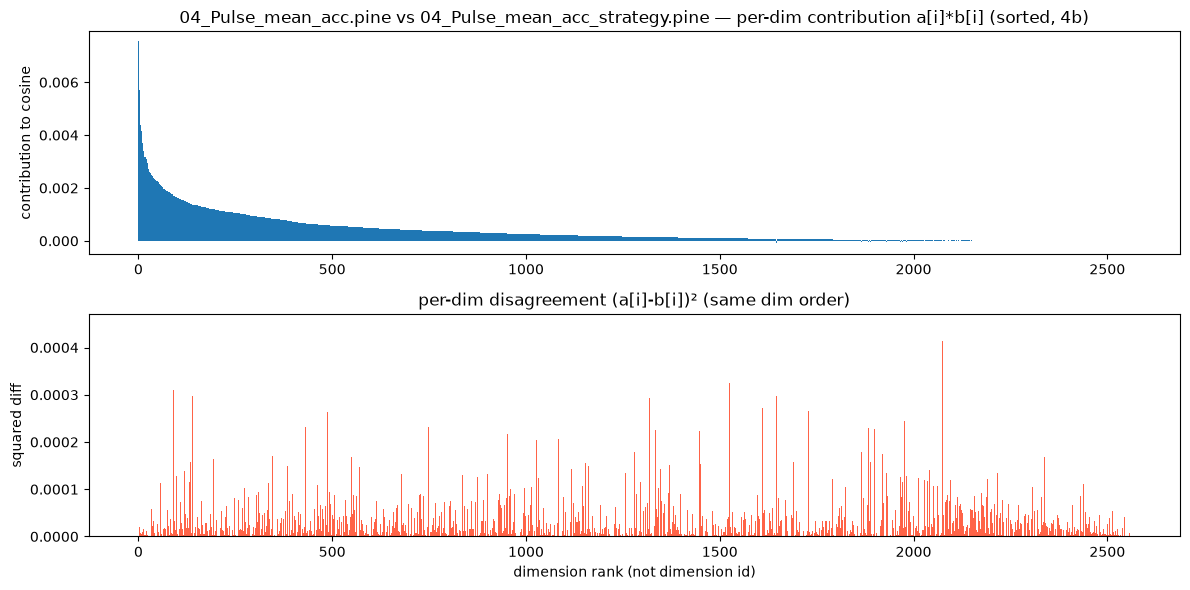

In [8]:
CONTRIB_MODEL = '4b'  # '0.6b' or '4b' — must be a key in MODELS

va, vb = MODELS[CONTRIB_MODEL][FILE_A], MODELS[CONTRIB_MODEL][FILE_B]
contrib = va * vb                      # sums to cos(a, b) — vectors are unit-norm
diff2 = (va - vb) ** 2                 # per-dim disagreement; sums to 2 - 2cos
order = np.argsort(-np.abs(contrib))   # most influential dims first

print(f'{CONTRIB_MODEL}: cos={contrib.sum():.4f}   2-2cos={diff2.sum():.4f}')
print(f'top-5 contributing dims: {order[:5].tolist()}  '
      f'({contrib[order[:5]].sum() / contrib.sum():.1%} of the score)')

try:
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
    ax1.bar(np.arange(len(contrib)), contrib[order], width=1.0)
    ax1.set_title(f'{FILE_A} vs {FILE_B} — per-dim contribution a[i]*b[i] '
                  f'(sorted, {CONTRIB_MODEL})')
    ax1.set_ylabel('contribution to cosine')
    ax2.bar(np.arange(len(diff2)), diff2[order], width=1.0, color='tomato')
    ax2.set_title('per-dim disagreement (a[i]-b[i])² (same dim order)')
    ax2.set_ylabel('squared diff')
    ax2.set_xlabel('dimension rank (not dimension id)')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib not installed — printing top-20 dims instead:')
    for d in order[:20]:
        print(f'  dim {d:>4}: a={va[d]:+.4f} b={vb[d]:+.4f} '
              f'contrib={contrib[d]:+.5f} diff2={diff2[d]:.5f}')